# 08. Hidden Markov Models (HMM): Market Regime Detection with hmmlearn
**Algorithm Covered:**
- **Hidden Markov Model (Gaussian HMM)**

**Core Mathematical Problems Addressed:**
1. **Evaluation:** Forward-Backward Algorithm ($P(X \mid \lambda)$)
2. **Decoding:** Viterbi Algorithm ($\arg\max_Z P(Z \mid X, \lambda)$)
3. **Learning:** Baum-Welch Expectation-Maximization Algorithm (EM)

**Dataset:** Financial Market Returns & Volatility Regimes (`data/market_regimes.csv`)
- Uncovering latent market dynamics: Bull (Low Volatility), Bear (High Volatility), and Sideways Regimes


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
# ---- hmmlearn: Gaussian Hidden Markov Model ----
from hmmlearn.hmm import GaussianHMM

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("hmmlearn loaded successfully!")


hmmlearn loaded successfully!


## 1. Dataset Loading and Exploratory Analysis
We examine daily financial asset returns exhibiting temporal volatility clustering and regime shifts.


In [2]:
# ---- Load the market returns dataset ----
df_market = pd.read_csv('../data/market_regimes.csv')
print("Market Data Preview:")
display(df_market.head())

# Observations for the HMM: daily returns (shape T x 1)
returns = df_market['Daily_Return'].values.reshape(-1, 1)
prices = df_market['Close'].values   # only used for visualization

# ---- Quick statistical summary ----
print(f"Total Trading Days: {len(df_market)}")
print(f"Mean Daily Return:   {np.mean(returns):.6f}")
print(f"Daily Return StdDev: {np.std(returns):.6f}")


Market Data Preview:


,Date,Close,Daily_Return,True_Regime
0,2020-01-01,99.41,-0.00587,0
1,2020-01-02,99.68,0.00271,0
2,2020-01-03,99.93,0.00247,0
3,2020-01-06,100.62,0.00686,0
4,2020-01-07,100.35,-0.00269,0


Total Trading Days: 1000
Mean Daily Return:   0.000115
Daily Return StdDev: 0.013194


## 2. Mathematical Formulation of Hidden Markov Models
An HMM characterizes a doubly stochastic process:
1. **Hidden State Sequence** $Z = (z_1, z_2, \dots, z_T)$ governed by a 1st-order Markov chain:
   $$P(z_t \mid z_{t-1}, \dots, z_1) = P(z_t \mid z_{t-1})$$
   defined by the **Transition Matrix** $A \in \mathbb{R}^{K \times K}$:
   $$A_{ij} = P(z_{t+1} = s_j \mid z_t = s_i)$$
2. **Observable Sequence** $X = (x_1, x_2, \dots, x_T)$ emitted from hidden states:
   $$x_t \mid (z_t = s_k) \sim \mathcal{N}(\mu_k, \sigma_k^2)$$

### The Viterbi Path (Decoding):
To recover the single most likely sequence of hidden states $Z^*$, dynamic programming tracks the maximal probability path $\delta_t(j)$:
$$\delta_t(j) = \max_{i} \left[ \delta_{t-1}(i) A_{ij} \right] \cdot b_j(x_t)$$
$$\psi_t(j) = \arg\max_{i} \left[ \delta_{t-1}(i) A_{ij} \right]$$
Backtracking from $T$ to 1 reconstructs $Z^*$.


### Step-by-Step Algorithm (Gaussian HMM)
1. **Model:** a hidden 1st-order Markov chain Z with transition matrix A, emitting observations x_t ~ N(μ_k, σ_k²) from the active state.
2. **Learning (Baum-Welch / EM):** iterate until convergence:
   a. **E-step:** run the forward-backward algorithm to compute posterior state probabilities γ_t(k) and ξ_t(i,j).
   b. **M-step:** re-estimate start probabilities, transition matrix A, and Gaussian parameters (μ_k, σ_k²) from the posteriors.
3. **Decoding (Viterbi):** dynamic programming finds the single most likely state sequence:
   δ_t(j) = max_i [δ_{t−1}(i) A_ij] · b_j(x_t); ψ_t(j) = argmax_i [...]; backtrack from T to 1.
4. **Evaluation:** the forward algorithm gives P(X | λ), reported as the model log-likelihood.
5. **Post-processing:** sort states by volatility so regime labels (Bull/Sideways/Bear) are stable and interpretable.


In [3]:
# ---- Fit a 3-state Gaussian HMM with the Baum-Welch (EM) algorithm ----
n_components = 3
hmm_model = GaussianHMM(
    n_components=n_components,        # Bull / Sideways / Bear regimes
    covariance_type="full",           # each state has its own full covariance Gaussian emission
    n_iter=200,                       # EM iterations
    random_state=42,
    verbose=False
)

hmm_model.fit(returns)
print("EM Training Converged:", hmm_model.monitor_.converged)
print(f"Model Log-Likelihood: {hmm_model.score(returns):.2f}")

# ---- Decode the most likely hidden state sequence with the Viterbi algorithm ----
hidden_states = hmm_model.predict(returns)

# ---- Sort regimes by volatility so labels have a consistent economic meaning ----
# Regime 0: Low Volatility (Bull) | Regime 1: Moderate (Sideways) | Regime 2: High (Bear/Crisis)
volatilities = [np.sqrt(hmm_model.covars_[i][0][0]) for i in range(n_components)]
state_order = np.argsort(volatilities)                                           # ascending volatility
state_mapping = {old_state: new_state for new_state, old_state in enumerate(state_order)}

sorted_hidden_states = np.array([state_mapping[s] for s in hidden_states])       # relabel sequence
sorted_means = [hmm_model.means_[old][0] for old in state_order]                 # reordered means
sorted_stds  = [np.sqrt(hmm_model.covars_[old][0][0]) for old in state_order]    # reordered std devs

# ---- Reorder the transition matrix to match the sorted regimes ----
sorted_transmat = np.zeros((n_components, n_components))
for i in range(n_components):
    for j in range(n_components):
        sorted_transmat[i, j] = hmm_model.transmat_[state_order[i], state_order[j]]

regime_names = ["Bull (Low Vol)", "Sideways (Med Vol)", "Bear (High Vol)"]


EM Training Converged: True
Model Log-Likelihood: 3018.45


In [4]:
# ---- Summary table of the discovered regimes ----
regime_summary = pd.DataFrame({
    "Regime Name": regime_names,
    "Mean Daily Return (μ)": [f"{m:.6f}" for m in sorted_means],               # average return per regime
    "Daily Volatility (σ)":  [f"{s:.6f}" for s in sorted_stds],                # daily std dev per regime
    "Annualized Volatility":  [f"{s * np.sqrt(252) * 100:.2f}%" for s in sorted_stds],  # x sqrt(252 trading days)
    "Observed Frequency":     [f"{np.mean(sorted_hidden_states == i)*100:.1f}%" for i in range(n_components)]  # % of days
}).set_index("Regime Name")

display(regime_summary)


,Mean Daily Return (μ),Daily Volatility (σ),Annualized Volatility,Observed Frequency
Regime Name,,,,
Bull (Low Vol),0.000508,0.010718,17.01%,44.2%
Sideways (Med Vol),0.000532,0.010797,17.14%,44.2%
Bear (High Vol),-0.002547,0.027882,44.26%,11.6%


## 3. Transition Matrix & Emission Distributions
The transition matrix elements $A_{ii}$ quantify **regime persistence**:
High diagonal values indicate that once the market enters a regime, it remains there with high probability.


### Reading the Transition Matrix & Emissions
1. Diagonal entries A_ii = probability of **staying** in the same regime (regime persistence).
2. Off-diagonal entries = probability of switching regimes next day.
3. Each emission curve shows the return distribution the model associates with a regime (low-vol vs high-vol).
4. Wider curves (larger σ) indicate more volatile regimes.


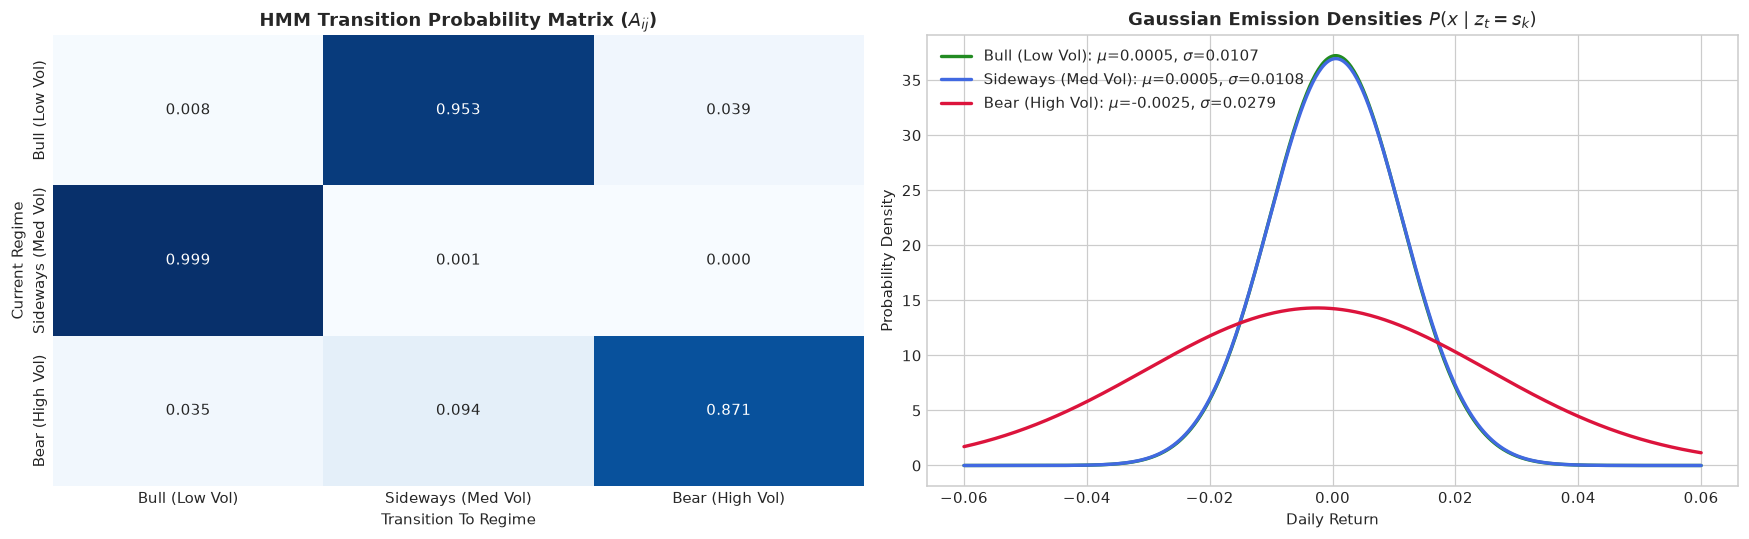

In [5]:
# ---- Transition matrix + emission densities ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: transition-probability heatmap (rows = current regime, cols = next regime)
sns.heatmap(sorted_transmat, annot=True, fmt='.3f', cmap='Blues', ax=ax1,
            xticklabels=regime_names, yticklabels=regime_names, cbar=False)
ax1.set_title("HMM Transition Probability Matrix ($A_{ij}$)", fontweight='bold')
ax1.set_xlabel("Transition To Regime")
ax1.set_ylabel("Current Regime")

# Panel 2: Gaussian emission densities per regime (P(return | regime))
x_axis = np.linspace(-0.06, 0.06, 500)
colors = ['forestgreen', 'royalblue', 'crimson']

for i in range(n_components):
    ax2.plot(x_axis, norm.pdf(x_axis, sorted_means[i], sorted_stds[i]),
             color=colors[i], lw=2.2, label=rf"{regime_names[i]}: $\mu$={sorted_means[i]:.4f}, $\sigma$={sorted_stds[i]:.4f}")

ax2.set_title(r"Gaussian Emission Densities $P(x \mid z_t = s_k)$", fontweight='bold')
ax2.set_xlabel("Daily Return")
ax2.set_ylabel("Probability Density")
ax2.legend()

plt.tight_layout()
plt.show()


## 4. Visualizing Viterbi Decoded Regimes Across Time
Let's overlay the decoded hidden market states on top of the asset price trajectory.


### Regime Visualization Process
1. Decode the full sequence with Viterbi (each day gets one regime label).
2. Color every consecutive price segment by the regime of that day.
3. Plot the state sequence in a second panel to see persistence and switch points.
4. Compare with the known market story: bull trends, sideways consolidation, volatility spikes.


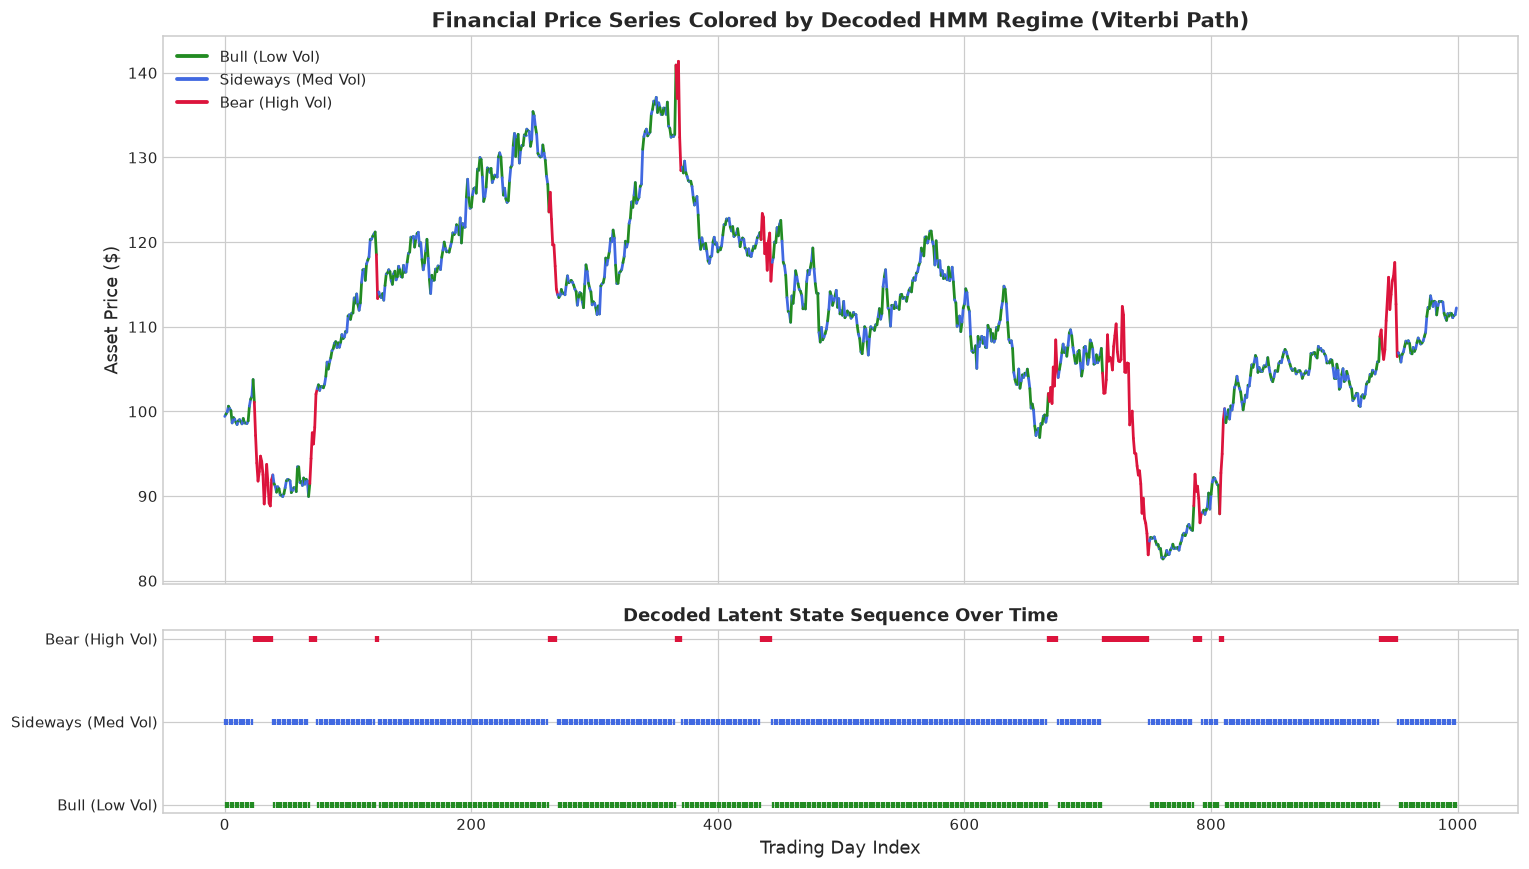

In [6]:
# ---- Overlay the Viterbi-decoded regimes on the price series ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top panel: draw each day-to-day price segment in the color of its decoded regime
for i in range(len(prices) - 1):
    reg = sorted_hidden_states[i]
    ax1.plot([i, i+1], [prices[i], prices[i+1]], color=colors[reg], lw=1.8)

# Legend handles (one per regime)
for i, name in enumerate(regime_names):
    ax1.plot([], [], color=colors[i], label=name, lw=2.5)

ax1.set_title("Financial Price Series Colored by Decoded HMM Regime (Viterbi Path)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Asset Price ($)", fontsize=12)
ax1.legend(loc='upper left')

# Bottom panel: the raw sequence of decoded states over time
ax2.scatter(range(len(sorted_hidden_states)), sorted_hidden_states, c=[colors[s] for s in sorted_hidden_states], s=15, marker='|')
ax2.set_yticks(range(n_components))
ax2.set_yticklabels(regime_names)
ax2.set_title("Decoded Latent State Sequence Over Time", fontsize=12, fontweight='bold')
ax2.set_xlabel("Trading Day Index", fontsize=12)

plt.tight_layout()
plt.show()


## 5. Summary & Key Takeaways
1. **Unsupervised Temporal Clustering**: Gaussian HMM discovers structural volatility shifts without requiring labeled market state annotations.
2. **Dynamic Transition Memory**: Unlike static mixture models, the Markov transition matrix captures state persistence and temporal autocorrelation.
3. **Viterbi Decoding**: Provides a globally optimal state trajectory that aligns with market cycles (Bull expansions, Sideways consolidations, and Bear volatility spikes).
